In [ ]:
# Import all the libraries you'll need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Set style for nice-looking graphs
sns.set_style('whitegrid')

# Load the dataset you uploaded
data = pd.read_csv('shipping.csv')

# Display the first 5 rows to make sure it loaded correctly
print("Data loaded successfully:")
print(data.head())

Data loaded successfully:
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44 


--- Analyzing Warehouse Performance (Objective 3) ---


KeyError: 'Column not found: Reached_on_time'

In [ ]:
# Run this to see all the real column names
print(data.columns)

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')



--- Analyzing Warehouse Performance (Objective 3) ---
  Warehouse_block  Reached.on.Time_Y.N
0               A             0.586470
2               C             0.596836
3               D             0.597601
4               F             0.598472
1               B             0.602291


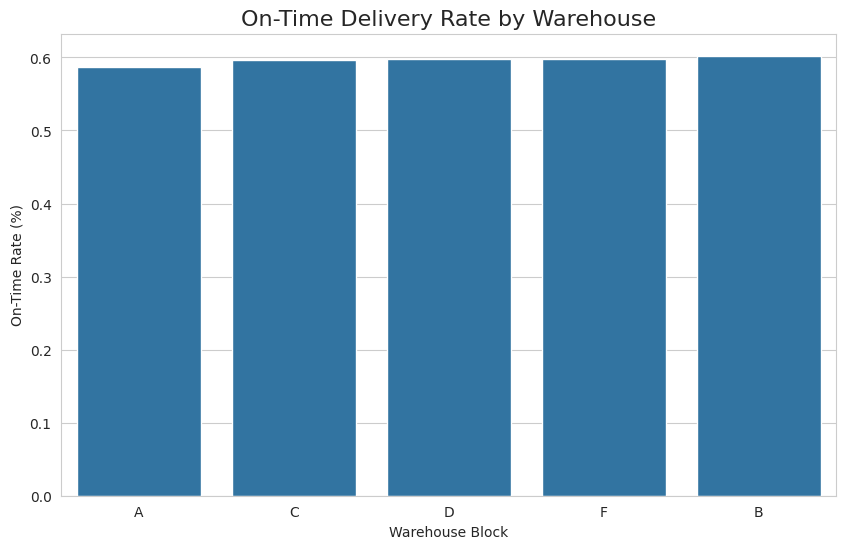


--- Analyzing Shipping Mode Performance (Objective 4) ---
  Mode_of_Shipment  Reached.on.Time_Y.N
1             Road             0.588068
2             Ship             0.597561
0           Flight             0.601576


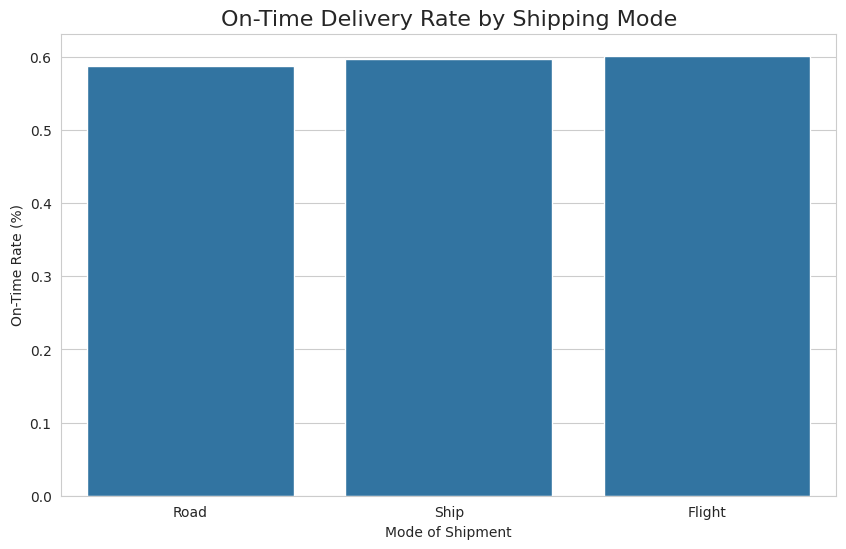

In [ ]:
# --- Objective 3: Improve Inventory (Finding the Bottleneck) ---

print("\n--- Analyzing Warehouse Performance (Objective 3) ---")
# Calculate the average on-time rate for each warehouse
# FIXED: Used 'Reached.on.Time_Y.N'
warehouse_perf = data.groupby('Warehouse_block')['Reached.on.Time_Y.N'].mean().reset_index()
warehouse_perf = warehouse_perf.sort_values(by='Reached.on.Time_Y.N')

print(warehouse_perf)

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Warehouse_block', y='Reached.on.Time_Y.N', data=warehouse_perf)
plt.title('On-Time Delivery Rate by Warehouse', fontsize=16)
plt.ylabel('On-Time Rate (%)')
plt.xlabel('Warehouse Block')
plt.savefig('warehouse_performance.png')
plt.show()


# --- Objective 4: Optimize Routes (Finding the best shipping mode) ---

print("\n--- Analyzing Shipping Mode Performance (Objective 4) ---")
# Calculate the average on-time rate for each shipping mode
# FIXED: Used 'Mode_of_Shipment' and 'Reached.on.Time_Y.N'
ship_mode_perf = data.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean().reset_index()
ship_mode_perf = ship_mode_perf.sort_values(by='Reached.on.Time_Y.N')

print(ship_mode_perf)

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Mode_of_Shipment', y='Reached.on.Time_Y.N', data=ship_mode_perf)
plt.title('On-Time Delivery Rate by Shipping Mode', fontsize=16)
plt.ylabel('On-Time Rate (%)')
plt.xlabel('Mode of Shipment')
plt.savefig('ship_mode_performance.png')
plt.show()


--- Building Delay Prediction Model (Objective 2) ---
Training the predictive model...
Model trained successfully.

Model Accuracy: 66.52%

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.66      0.61      1312
           1       0.75      0.67      0.71      1988

    accuracy                           0.67      3300
   macro avg       0.66      0.66      0.66      3300
weighted avg       0.68      0.67      0.67      3300


--- Feature Importances (What causes delays?) ---
Weight_in_gms          0.470468
Cost_of_the_Product    0.267668
Prior_purchases        0.069012
Warehouse_block        0.065157
Customer_care_calls    0.059414
Mode_of_Shipment       0.034906
Product_importance     0.033375
dtype: float64


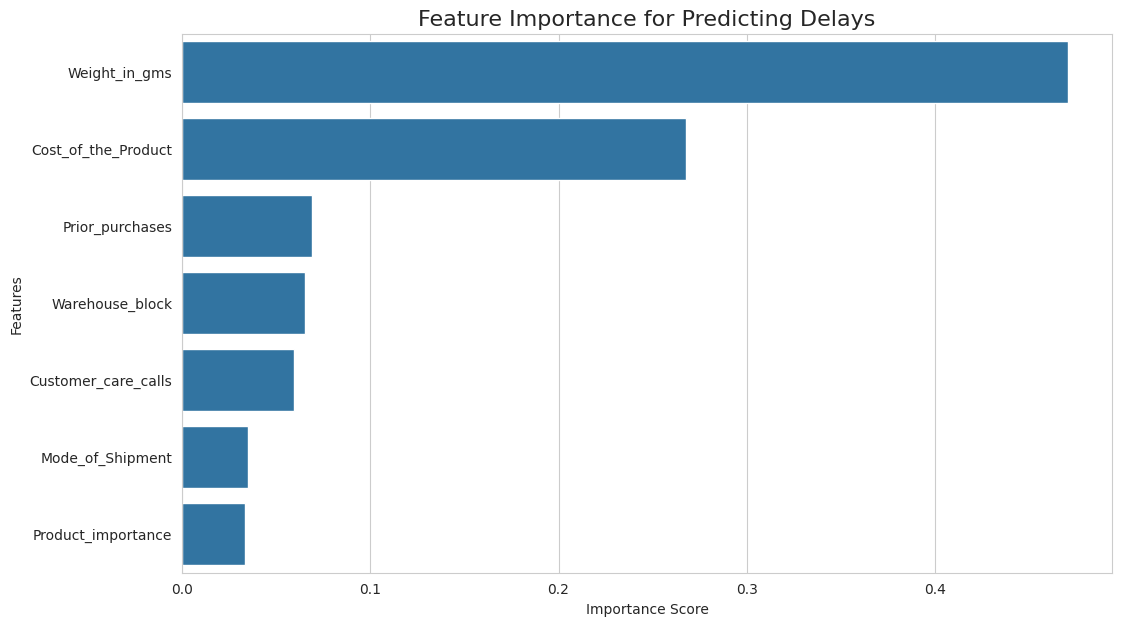

In [ ]:
print("\n--- Building Delay Prediction Model (Objective 2) ---")

# --- 1. Preprocessing (Convert text to numbers) ---
model_data = data.copy()
# FIXED: Used 'Mode_of_Shipment'
categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

for col in categorical_cols:
    le = LabelEncoder()
    model_data[col] = le.fit_transform(model_data[col])

# --- 2. Define Features (X) and Target (y) ---
# FIXED: Used 'Mode_of_Shipment', 'Cost_of_the_Product'
features = ['Warehouse_block', 'Mode_of_Shipment', 'Cost_of_the_Product',
            'Prior_purchases', 'Product_importance', 'Weight_in_gms',
            'Customer_care_calls']
# FIXED: Used 'Reached.on.Time_Y.N'
target = 'Reached.on.Time_Y.N'

X = model_data[features]
y = model_data[target]

# --- 3. Split Data into Training and Testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 4. Train the Model ---
print("Training the predictive model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully.")

# --- 5. Evaluate the Model (Get Findings for your Report) ---
y_pred = model.predict(X_test)

print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 6. Find "Feature Importance" (What causes delays?) ---
feat_importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

print("\n--- Feature Importances (What causes delays?) ---")
print(feat_importance)

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title('Feature Importance for Predicting Delays', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.savefig('feature_importance.png')
plt.show()

In [ ]:
print("\n--- Key Performance Indicators (KPIs) (Objective 5) ---")

# Calculate overall on-time rate
# FIXED: Used 'Reached.on.Time_Y.N'
total_on_time_rate = data['Reached.on.Time_Y.N'].mean()
print(f"Overall On-Time Delivery Rate: {total_on_time_rate:.2%}")

# Calculate average customer care calls for delayed shipments
# FIXED: Used 'Reached.on.Time_Y.N'
delayed_shipments = data[data['Reached.on.Time_Y.N'] == 0]
avg_calls_on_delay = delayed_shipments['Customer_care_calls'].mean()
print(f"Avg. Customer Calls on Delayed Shipments: {avg_calls_on_delay:.2f}")


--- Key Performance Indicators (KPIs) (Objective 5) ---
Overall On-Time Delivery Rate: 59.67%
Avg. Customer Calls on Delayed Shipments: 4.15
